## 1. Import Required Libraries

In [1]:
!pip -q install imbalanced-learn xgboost joblib

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import joblib


Matplotlib is building the font cache; this may take a moment.


## 2. Load and Prepare Data

In [3]:
# Update path according to your file
df = pd.read_csv("Fraud.csv")

print(df.shape)
df.head()


(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Separate both classes
df_fraud = df[df["isFraud"] == 1]
df_legit = df[df["isFraud"] == 0]

# Take 10% from each class
df_fraud_10 = df_fraud.sample(frac=0.10, random_state=42)
df_legit_10 = df_legit.sample(frac=0.10, random_state=42)

# Combine + shuffle
df = pd.concat([df_fraud_10, df_legit_10], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print("Using 10% dataset shape:", df.shape)
print("\nClass counts:\n", df["isFraud"].value_counts())
print("\nClass %:\n", df["isFraud"].value_counts(normalize=True) * 100)


Using 10% dataset shape: (636262, 11)

Class counts:
 isFraud
0    635441
1       821
Name: count, dtype: int64

Class %:
 isFraud
0    99.870965
1     0.129035
Name: proportion, dtype: float64


In [5]:
df.to_csv("Fraud_10pct.csv", index=False)

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636262 entries, 0 to 636261
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            636262 non-null  int64  
 1   type            636262 non-null  object 
 2   amount          636262 non-null  float64
 3   nameOrig        636262 non-null  object 
 4   oldbalanceOrg   636262 non-null  float64
 5   newbalanceOrig  636262 non-null  float64
 6   nameDest        636262 non-null  object 
 7   oldbalanceDest  636262 non-null  float64
 8   newbalanceDest  636262 non-null  float64
 9   isFraud         636262 non-null  int64  
 10  isFlaggedFraud  636262 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 53.4+ MB
None


In [7]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [8]:
print("\nTarget distribution:\n", df["isFraud"].value_counts())


Target distribution:
 isFraud
0    635441
1       821
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

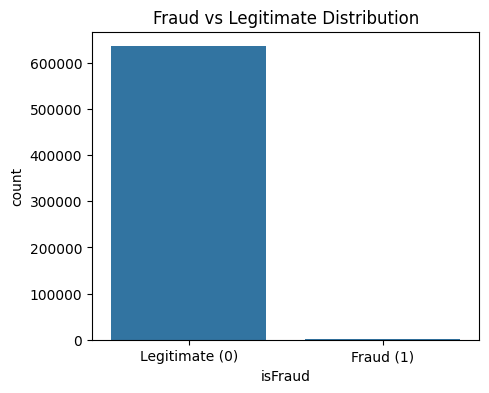

In [9]:
plt.figure(figsize=(5,4))
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Legitimate Distribution")
plt.xticks([0,1], ["Legitimate (0)", "Fraud (1)"])
plt.show()


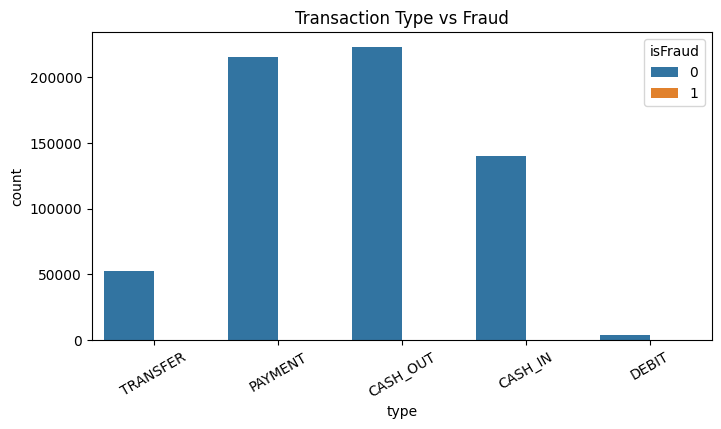

In [10]:
plt.figure(figsize=(8,4))
sns.countplot(x="type", hue="isFraud", data=df)
plt.title("Transaction Type vs Fraud")
plt.xticks(rotation=30)
plt.show()


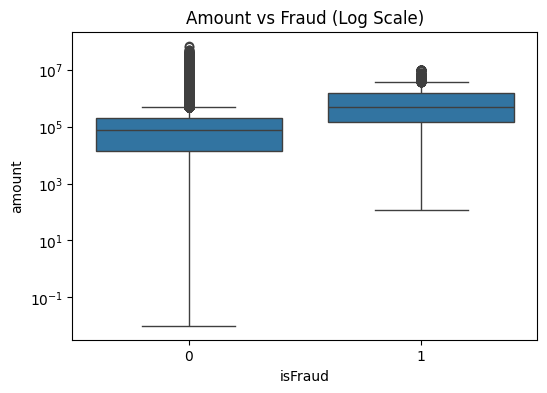

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x="isFraud", y="amount", data=df)
plt.yscale("log")
plt.title("Amount vs Fraud (Log Scale)")
plt.show()


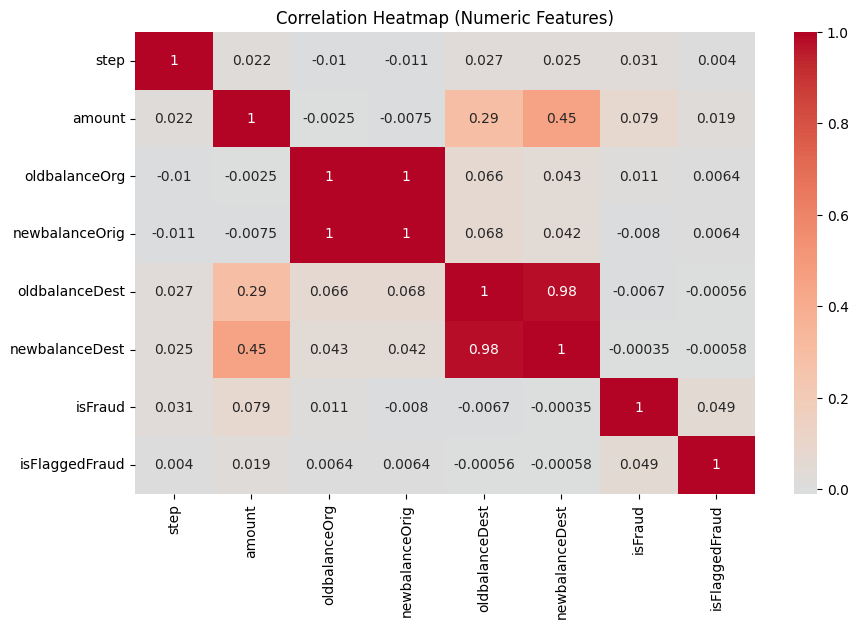

In [12]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [13]:
df = df.copy()

df["orig_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_diff"] = df["newbalanceDest"] - df["oldbalanceDest"]

# Optional: if combined_fraud is not needed, keep it out of training features
# We'll still keep it in df, but not use it in X later unless you want.
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_balance_diff,dest_balance_diff
0,277,TRANSFER,180953.49,C1454816660,56248.00,0.0,C68563177,3297829.65,3478783.14,0,0,56248.00,180953.49
1,142,PAYMENT,11402.44,C201915217,0.00,0.0,M486816922,0.00,0.00,0,0,0.00,0.00
2,278,PAYMENT,6780.51,C906009940,5209.67,0.0,M380968780,0.00,0.00,0,0,5209.67,0.00
3,11,TRANSFER,1872725.28,C2124244867,62119.30,0.0,C980380973,113185.11,3066956.05,0,0,62119.30,2953770.94
4,408,TRANSFER,1059338.33,C1595665401,7766.00,0.0,C1565330864,4593165.60,5652503.93,0,0,7766.00,1059338.33


In [14]:
df_model = df.copy()

# Drop ID-like columns
df_model.drop(["nameOrig", "nameDest"], axis=1, inplace=True, errors="ignore")

# One-hot encode type
df_model = pd.get_dummies(df_model, columns=["type"], drop_first=True)

df_model.head()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_balance_diff,dest_balance_diff,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,277,180953.49,56248.00,0.0,3297829.65,3478783.14,0,0,56248.00,180953.49,False,False,False,True
1,142,11402.44,0.00,0.0,0.00,0.00,0,0,0.00,0.00,False,False,True,False
2,278,6780.51,5209.67,0.0,0.00,0.00,0,0,5209.67,0.00,False,False,True,False
3,11,1872725.28,62119.30,0.0,113185.11,3066956.05,0,0,62119.30,2953770.94,False,False,False,True
4,408,1059338.33,7766.00,0.0,4593165.60,5652503.93,0,0,7766.00,1059338.33,False,False,False,True


In [15]:
target_col = "isFraud"

y = df_model[target_col].astype(int)

X = df_model.drop(columns=[target_col, "combined_fraud"], errors="ignore")

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (636262, 13)
y shape: (636262,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class ratio:\n", y_train.value_counts(normalize=True))
print("Test class ratio:\n", y_test.value_counts(normalize=True))


Train: (509009, 13) Test: (127253, 13)
Train class ratio:
 isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64
Test class ratio:
 isFraud
0    0.998711
1    0.001289
Name: proportion, dtype: float64


Before SMOTE:
 isFraud
0    508352
1       657
Name: count, dtype: int64

After SMOTE:
 isFraud
0    508352
1    508352
Name: count, dtype: int64


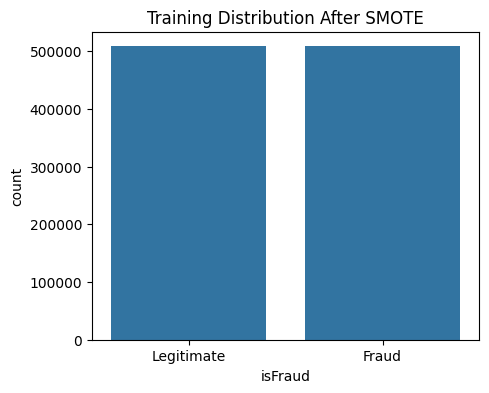

In [17]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_sm).value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x=y_train_sm)
plt.title("Training Distribution After SMOTE")
plt.xticks([0,1], ["Legitimate", "Fraud"])
plt.show()


In [18]:
def plot_confusion(cm, title="Confusion Matrix"):
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

def plot_roc(y_true, y_proba, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{title} (AUC={auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

def plot_pr(y_true, y_proba, title="Precision-Recall Curve"):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(recall, precision)
    plt.title(f"{title} (AP={ap:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

def evaluate_model(model_name, y_true, y_pred, y_proba):
    print(f"\n========== {model_name} ==========")
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plot_confusion(cm, title=f"{model_name} - Confusion Matrix")

    auc = roc_auc_score(y_true, y_proba)
    ap  = average_precision_score(y_true, y_proba)
    print(f"ROC-AUC: {auc:.4f}")
    print(f"PR-AUC (Average Precision): {ap:.4f}")

    plot_roc(y_true, y_proba, title=f"{model_name} ROC")
    plot_pr(y_true, y_proba, title=f"{model_name} PR")



========== LR (Class Weighted) ==========
              precision    recall  f1-score   support

           0     0.9996    0.9993    0.9994    127089
           1     0.5583    0.7012    0.6216       164

    accuracy                         0.9989    127253
   macro avg     0.7789    0.8503    0.8105    127253
weighted avg     0.9990    0.9989    0.9990    127253



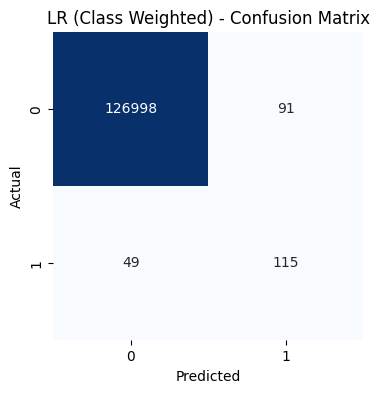

ROC-AUC: 0.9891
PR-AUC (Average Precision): 0.7105


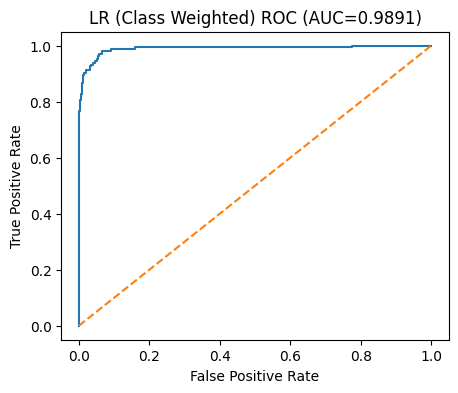

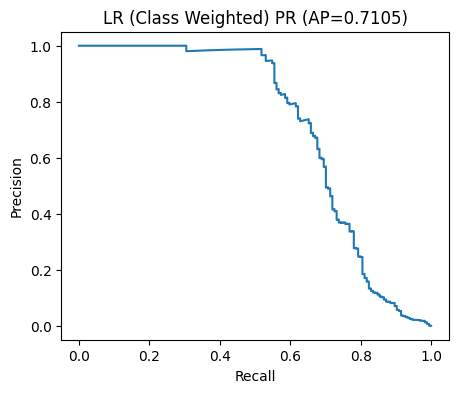

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr = scaler.fit_transform(X_train)
X_test_lr  = scaler.transform(X_test)

lr_weighted = LogisticRegression(
    max_iter=2000,
    class_weight={0:1, 1:10},  # tune this
    solver="lbfgs"
)

lr_weighted.fit(X_train_lr, y_train)

y_pred = lr_weighted.predict(X_test_lr)
y_proba_lr = lr_weighted.predict_proba(X_test_lr)[:,1]

evaluate_model("LR (Class Weighted)", y_test, y_pred, y_proba_lr)


========== RF (Class Weighted) ==========
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9998    127089
           1     0.9841    0.7561    0.8552       164

    accuracy                         0.9997    127253
   macro avg     0.9919    0.8780    0.9275    127253
weighted avg     0.9997    0.9997    0.9996    127253



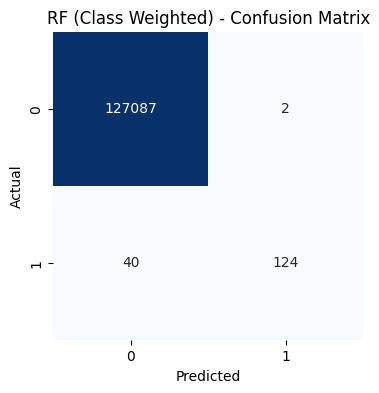

ROC-AUC: 0.9903
PR-AUC (Average Precision): 0.8929


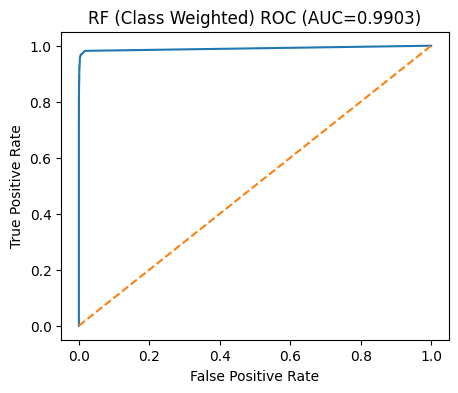

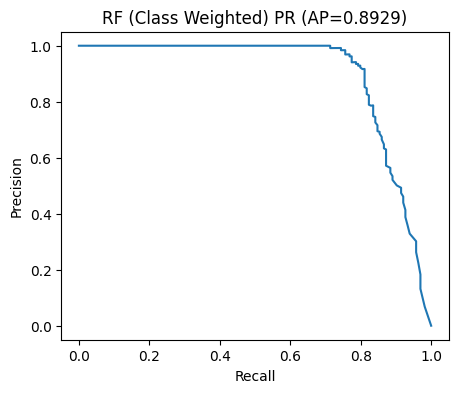

In [20]:
rf_weighted = RandomForestClassifier(
    n_estimators=300,
    class_weight={0:1, 1:10},  # emphasize fraud
    random_state=42,
    n_jobs=1
)

rf_weighted.fit(X_train, y_train)

y_pred_w = rf_weighted.predict(X_test)
y_proba_rf = rf_weighted.predict_proba(X_test)[:,1]

evaluate_model("RF (Class Weighted)", y_test, y_pred_w, y_proba_rf)

773.7473363774734

========== XGBoost (Weighted) ==========
              precision    recall  f1-score   support

           0     0.9999    0.9988    0.9993    127089
           1     0.4887    0.9207    0.6385       164

    accuracy                         0.9987    127253
   macro avg     0.7443    0.9597    0.8189    127253
weighted avg     0.9992    0.9987    0.9989    127253



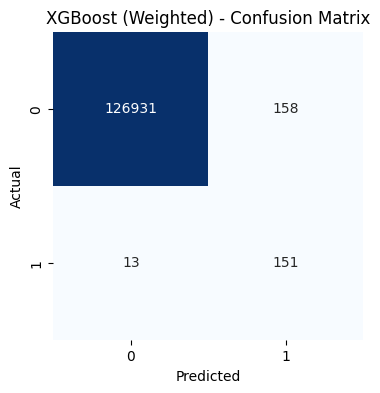

ROC-AUC: 0.9939
PR-AUC (Average Precision): 0.9096


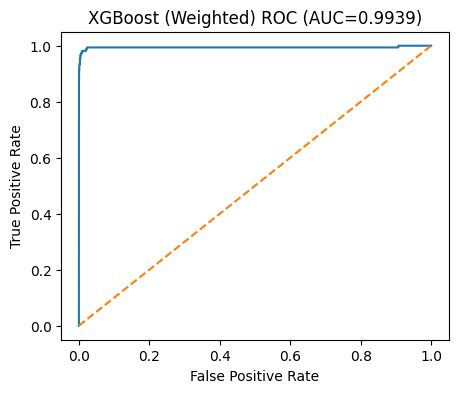

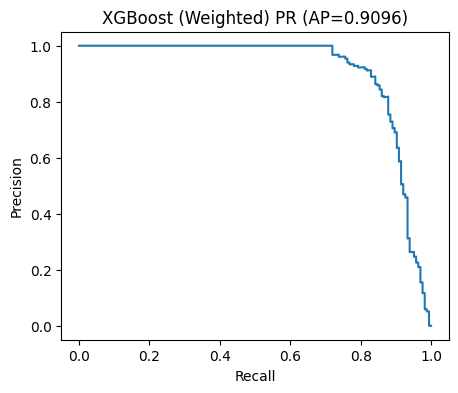

In [21]:
# Compute ratio
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(scale_pos_weight)

xgb_weighted = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

xgb_weighted.fit(X_train, y_train)

y_pred = xgb_weighted.predict(X_test)
y_proba_xgb = xgb_weighted.predict_proba(X_test)[:,1]

evaluate_model("XGBoost (Weighted)", y_test, y_pred, y_proba_xgb)


In [22]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression (Class Weighted)",
        "Random Forest (Class Weighted)",
        "XGBoost (Weighted)"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    "PR_AUC": [
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_rf),
        average_precision_score(y_test, y_proba_xgb)
    ]
})

results = results.sort_values(by="PR_AUC", ascending=False)
results


,Model,ROC_AUC,PR_AUC
2,XGBoost (Weighted),0.993913,0.909650
1,Random Forest (Class Weighted),0.990326,0.892932
0,Logistic Regression (Class Weighted),0.989086,0.710465


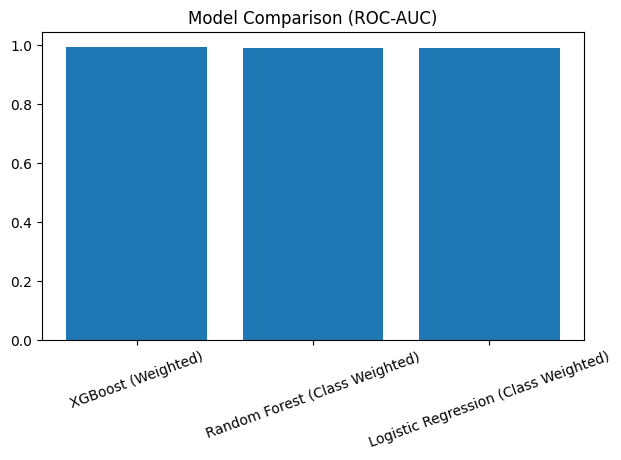

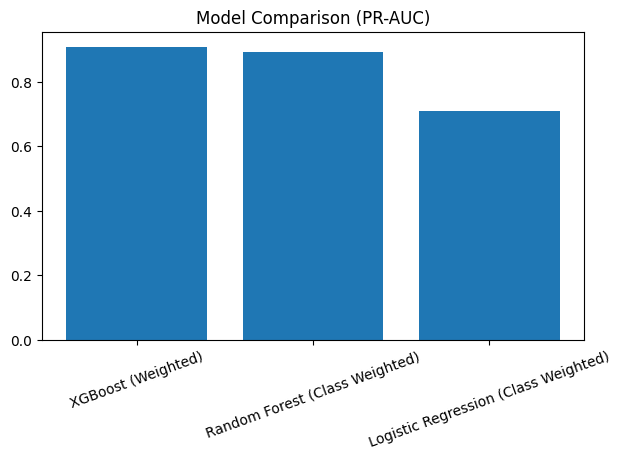

In [23]:
plt.figure(figsize=(7,4))
plt.bar(results["Model"], results["ROC_AUC"])
plt.title("Model Comparison (ROC-AUC)")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
plt.bar(results["Model"], results["PR_AUC"])
plt.title("Model Comparison (PR-AUC)")
plt.xticks(rotation=20)
plt.show()


In [24]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Save Logistic Regression (Class Weighted)
joblib.dump(lr_weighted, "models/logistic_regression.pkl")
joblib.dump(scaler, "models/lr_scaler.pkl")

# Save Random Forest (Class Weighted)
joblib.dump(rf_weighted, "models/random_forest.pkl")


# Save feature columns
joblib.dump(list(X.columns), "models/feature_columns.pkl")

# Save XGBoost model using native method
xgb_weighted.save_model("models/xgboost.json")

print("All models saved successfully in /models folder")


All models saved successfully in /models folder
